## A. Préparation de données

In [1]:
import pandas as pd
path = "cleaned_data.csv"
df = pd.read_csv(path)
df.head(10)


FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_data.csv'

In [4]:
print(df.isnull().sum())

# df = df.dropna(subset=['cleaned_text'])

id              0
author          0
cleaned_text    0
dtype: int64


## Check Class Distribution (Imbalance Analysis)

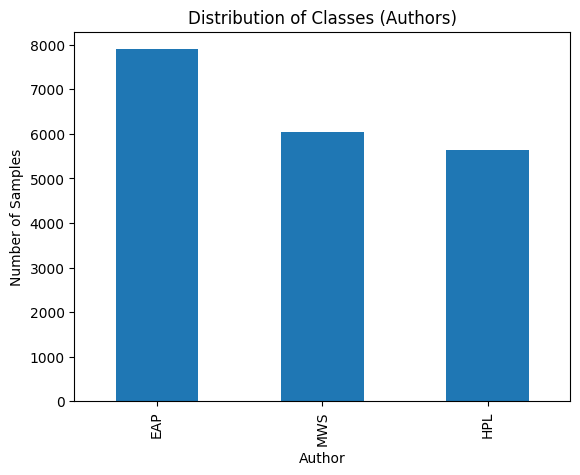

author
EAP    7898
MWS    6043
HPL    5635
Name: count, dtype: int64

In [5]:
import matplotlib.pyplot as plt

df['author'].value_counts().plot(kind='bar')

plt.title("Distribution of Classes (Authors)")
plt.xlabel("Author")
plt.ylabel("Number of Samples")
plt.show()

df['author'].value_counts()

## B. Encodage de la variable à prédire (facultatif)

l’encodage OneHot.

In [6]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=False)

encoded_labels = encoder.fit_transform(df[['author']])

encoded_df = pd.DataFrame(encoded_labels, columns=encoder.categories_[0]).astype(int)

df = pd.concat([df, encoded_df], axis=1)

df.head(10)


,id,author,cleaned_text,EAP,HPL,MWS
0,id26305,EAP,process however aforded aforded means ascerta...,1.0,0.0,0.0
1,id17569,HPL,never ocured fumbling might mere mistake,0.0,1.0,0.0
2,id11008,EAP,left hand gold snuff box capered hill cutting ...,1.0,0.0,0.0
3,id27763,MWS,lovely spring loked windsor terace sixteen fer...,0.0,0.0,1.0
4,id12958,HPL,finding nothing else even gold superintendent ...,0.0,1.0,0.0
5,id22965,MWS,youth pased solitude best years spent gentle f...,0.0,0.0,1.0
6,id09674,EAP,astronomer perhaps point took refuge suggestio...,1.0,0.0,0.0
7,id13515,EAP,surcingle hung ribands body,1.0,0.0,0.0
8,id19322,EAP,knew could say stereotomy without brought thin...,1.0,0.0,0.0
9,id00912,MWS,confess neither structure languages code gover...,0.0,0.0,1.0


In [9]:
print(df.isnull().sum())

# df = df.dropna()

id              0
author          0
cleaned_text    0
EAP             0
HPL             0
MWS             0
dtype: int64


## C. Construction des bases d’entraînement et de test

1. Diviser le dataset en deux parties : entrainement et test, en utilisant train_test_split, la taille du test 30%
et random_state=0.

In [10]:
from sklearn.model_selection import train_test_split

X = df[['cleaned_text']]  
y = df[['author']]  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print("Training set size:", train_df.shape)
print("Test set size:", test_df.shape)


Training set size: (13701, 2)
Test set size: (5872, 2)


In [11]:
print("Distribution des classes dans y :")
print(y.value_counts(normalize=True))

print("\nDistribution des classes dans y_train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution des classes dans y_test :")
print(y_test.value_counts(normalize=True))


Distribution des classes dans y :
author
EAP       0.403413
MWS       0.308742
HPL       0.287846
Name: proportion, dtype: float64

Distribution des classes dans y_train :
author
EAP       0.403401
MWS       0.308737
HPL       0.287862
Name: proportion, dtype: float64

Distribution des classes dans y_test :
author
EAP       0.403440
MWS       0.308753
HPL       0.287807
Name: proportion, dtype: float64


2. Le dataset est déséquilibré (Imbalanced dataset), stratifier les échantillons de manière à obtenir
une répartition similaire dans chaque classe du dataset.

In [12]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

y = df["author"]  
X = df[["cleaned_text"]]  

oversampler = RandomOverSampler(random_state=0)

X_resampled, y_resampled = oversampler.fit_resample(X, y)

df_resampled = pd.DataFrame({"cleaned_text": X_resampled["cleaned_text"], "author": y_resampled})

print(df_resampled["author"].value_counts())


author
EAP    7896
HPL    7896
MWS    7896
Name: count, dtype: int64


## D. Méthodes de vectorisation

1. Utiliser la méthode de fréquence lexicale et one-hot encoding pour vectoriser le dataset d’entrainement et
du test.

📌 Lexical Frequency (CountVectorizer)

In [13]:
df.head()

,id,author,cleaned_text,EAP,HPL,MWS
0,id26305,EAP,process however aforded aforded means ascerta...,1.0,0.0,0.0
1,id17569,HPL,never ocured fumbling might mere mistake,0.0,1.0,0.0
2,id11008,EAP,left hand gold snuff box capered hill cutting ...,1.0,0.0,0.0
3,id27763,MWS,lovely spring loked windsor terace sixteen fer...,0.0,0.0,1.0
4,id12958,HPL,finding nothing else even gold superintendent ...,0.0,1.0,0.0


In [14]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer()

X_train_bow = bow_vectorizer.fit_transform(X_train['cleaned_text'])

X_test_bow = bow_vectorizer.transform(X_test['cleaned_text'])

print("BoW Training Data Shape:", X_train_bow.shape)
print("BoW Test Data Shape:", X_test_bow.shape)


BoW Training Data Shape: (13701, 22061)
BoW Test Data Shape: (5872, 22061)


JUST FOR TESTING  

In [15]:
X_test_sample = df['cleaned_text'][:5]

X_test_sample_vectorized = bow_vectorizer.fit_transform(X_test_sample)

df_vectorized = pd.DataFrame(X_test_sample_vectorized.toarray(), columns=bow_vectorizer.get_feature_names_out())

print(df_vectorized)

   abandoned  aforded  air  ascertaining  atempts  aware  beneath  box  \
0          0        2    0             1        0      1        0    0   
1          0        0    0             0        0      0        0    0   
2          0        0    1             0        0      0        0    1   
3          0        0    0             0        0      0        1    0   
4          1        0    0             0        1      0        0    0   

   capered  cheering  ...  thinking  took  towns  uniform  wall  wealthier  \
0        0         0  ...         0     0      0        1     1          0   
1        0         0  ...         0     0      0        0     0          0   
2        1         0  ...         0     1      0        0     0          0   
3        0         1  ...         0     0      1        0     0          1   
4        0         0  ...         1     0      0        0     0          0   

   whence  windsor  without  years  
0       1        0        1      0  
1       0   

📌 One-Hot Encoding (Binary Representation)

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

onehot_vectorizer = CountVectorizer(binary=True)

X_train_onehot = onehot_vectorizer.fit_transform(X_train['cleaned_text'])

X_test_onehot = onehot_vectorizer.transform(X_test['cleaned_text'])

print("One-Hot Encoding Training Shape:", X_train_onehot.shape)
print("One-Hot Encoding Test Shape:", X_test_onehot.shape)


One-Hot Encoding Training Shape: (13701, 22061)
One-Hot Encoding Test Shape: (5872, 22061)


JUST FOR TESTING

In [17]:
X_test_sample = df['cleaned_text'][:5]

X_test_sample_vectorized = onehot_vectorizer.fit_transform(X_test_sample)

df_vectorized = pd.DataFrame(X_test_sample_vectorized.toarray(), columns=onehot_vectorizer.get_feature_names_out())

print(df_vectorized)

   abandoned  aforded  air  ascertaining  atempts  aware  beneath  box  \
0          0        1    0             1        0      1        0    0   
1          0        0    0             0        0      0        0    0   
2          0        0    1             0        0      0        0    1   
3          0        0    0             0        0      0        1    0   
4          1        0    0             0        1      0        0    0   

   capered  cheering  ...  thinking  took  towns  uniform  wall  wealthier  \
0        0         0  ...         0     0      0        1     1          0   
1        0         0  ...         0     0      0        0     0          0   
2        1         0  ...         0     1      0        0     0          0   
3        0         1  ...         0     0      1        0     0          1   
4        0         0  ...         1     0      0        0     0          0   

   whence  windsor  without  years  
0       1        0        1      0  
1       0   

2. Entrainer un modèle de vectorisation TF-IDF(Term Frequency - Inverse Document Frequency) sur la partie d’entrainement et vectorisez-le.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['cleaned_text'])

X_test_tfidf = tfidf_vectorizer.transform(X_test['cleaned_text'])

print("TF-IDF Matrix Shape (Training Data):", X_train_tfidf.shape)
print("TF-IDF Matrix Shape (Test Data):", X_test_tfidf.shape)

print("First 10 words in TF-IDF Vocabulary:", tfidf_vectorizer.get_feature_names_out()[:10])



TF-IDF Matrix Shape (Training Data): (13701, 22061)
TF-IDF Matrix Shape (Test Data): (5872, 22061)
First 10 words in TF-IDF Vocabulary: ['ab' 'aback' 'abandon' 'abandoned' 'abandoning' 'abandonment' 'abaout'
 'abashed' 'abashment' 'abate']


JUST TESTING

In [19]:
X_test_sample = df['cleaned_text'][:5]

X_test_sample_vectorized = tfidf_vectorizer.fit_transform(X_test_sample)

df_vectorized = pd.DataFrame(X_test_sample_vectorized.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print(df_vectorized)

   abandoned  aforded       air  ascertaining   atempts     aware   beneath  \
0   0.000000  0.41125  0.000000      0.205625  0.000000  0.205625  0.000000   
1   0.000000  0.00000  0.000000      0.000000  0.000000  0.000000  0.000000   
2   0.000000  0.00000  0.220055      0.000000  0.000000  0.000000  0.000000   
3   0.000000  0.00000  0.000000      0.000000  0.000000  0.000000  0.208514   
4   0.252773  0.00000  0.000000      0.000000  0.252773  0.000000  0.000000   

        box   capered  cheering  ...  thinking      took     towns   uniform  \
0  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.205625   
1  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
2  0.220055  0.220055  0.000000  ...  0.000000  0.220055  0.000000  0.000000   
3  0.000000  0.000000  0.208514  ...  0.000000  0.000000  0.208514  0.000000   
4  0.000000  0.000000  0.000000  ...  0.252773  0.000000  0.000000  0.000000   

       wall  wealthier    whence   windsor  

## E. Entrainement

1. Créer trois modèles du type MLPClassifier. (Vous pouvez changer l’algorithme d’apprentissage : utiliser
les autres algorithmes de scikit-learn)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_bow = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=0)

In [129]:
mlp_onehot = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=0)


In [130]:
mlp_tfidf = MLPClassifier(hidden_layer_sizes=(100,),alpha=0.01, max_iter=500, random_state=0)

2. Entrainer ces trois modèles sur les trois représentations vectorielles.

In [131]:
mlp_bow.fit(X_train_bow, y_train)

c:\Users\ikram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(max_iter=500, random_state=0)

In [132]:

mlp_onehot.fit(X_train_onehot, y_train)


c:\Users\ikram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(max_iter=500, random_state=0)

In [133]:
mlp_tfidf.fit(X_train_tfidf, y_train)

c:\Users\ikram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(alpha=0.01, max_iter=500, random_state=0)

3. Prédire les classes en appliquant les trois modèles sur les trois représentations d’entrainement.
4. Afficher le rapport de classification en utilisant les mesures de performance (accuracy, precision,
recall...).

In [134]:
from sklearn.metrics import classification_report

y_train_pred_bow = mlp_bow.predict(X_train_bow)  
print("🔹 BoW Representation Training Performance:")
print(classification_report(y_train, y_train_pred_bow))

y_train_pred_onehot = mlp_onehot.predict(X_train_onehot)  
print("\n🔹 One-Hot Encoding Training Performance:")
print(classification_report(y_train, y_train_pred_onehot))

y_train_pred_tfidf = mlp_tfidf.predict(X_train_tfidf)  
print("\n🔹 TF-IDF Training Performance:")
print(classification_report(y_train, y_train_pred_tfidf))


🔹 BoW Representation Training Performance:
              precision    recall  f1-score   support

         EAP       1.00      1.00      1.00      5527
         HPL       1.00      1.00      1.00      3944
         MWS       1.00      1.00      1.00      4230

    accuracy                           1.00     13701
   macro avg       1.00      1.00      1.00     13701
weighted avg       1.00      1.00      1.00     13701


🔹 One-Hot Encoding Training Performance:
              precision    recall  f1-score   support

         EAP       1.00      1.00      1.00      5527
         HPL       1.00      1.00      1.00      3944
         MWS       1.00      1.00      1.00      4230

    accuracy                           1.00     13701
   macro avg       1.00      1.00      1.00     13701
weighted avg       1.00      1.00      1.00     13701


🔹 TF-IDF Training Performance:
              precision    recall  f1-score   support

         EAP       1.00      1.00      1.00      5527
         HPL

## F. TEST

1. Prédire les classes en appliquant les trois modèles sur les trois représentations de test.
2. Afficher le rapport de classification en utilisant les mesures de performance (accuracy, precision,
recall...)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_test_pred_bow = mlp_bow.predict(X_test_bow)
accuracy_bow = accuracy_score(y_test, y_test_pred_bow)
print(f"🔹 BoW Representation Test Accuracy: {accuracy_bow:.4f}")
print(classification_report(y_test, y_test_pred_bow))

y_test_pred_onehot = mlp_onehot.predict(X_test_onehot)
accuracy_onehot = accuracy_score(y_test, y_test_pred_onehot)
print(f"\n🔹 One-Hot Encoding Test Accuracy: {accuracy_onehot:.4f}")
print(classification_report(y_test, y_test_pred_onehot))

y_test_pred_tfidf = mlp_tfidf.predict(X_test_tfidf)
accuracy_tfidf = accuracy_score(y_test, y_test_pred_tfidf)
print(f"\n🔹 TF-IDF Test Accuracy: {accuracy_tfidf:.4f}")
print(classification_report(y_test, y_test_pred_tfidf))


🔹 BoW Representation Test Accuracy: 0.7580
              precision    recall  f1-score   support

         EAP       0.75      0.77      0.76      2369
         HPL       0.79      0.73      0.76      1690
         MWS       0.74      0.76      0.75      1813

    accuracy                           0.76      5872
   macro avg       0.76      0.76      0.76      5872
weighted avg       0.76      0.76      0.76      5872


🔹 One-Hot Encoding Test Accuracy: 0.7563
              precision    recall  f1-score   support

         EAP       0.75      0.77      0.76      2369
         HPL       0.79      0.73      0.76      1690
         MWS       0.74      0.76      0.75      1813

    accuracy                           0.76      5872
   macro avg       0.76      0.75      0.76      5872
weighted avg       0.76      0.76      0.76      5872


🔹 TF-IDF Test Accuracy: 0.7807
              precision    recall  f1-score   support

         EAP       0.78      0.80      0.79      2369
         HPL

3. Calculer le temps de prédiction pour chaque modèle

In [ ]:
import time

start_time = time.time()
y_test_pred_bow = mlp_bow.predict(X_test_bow)
bow_time = time.time() - start_time
print(f"⏳ Prediction Time (BoW): {bow_time:.4f} seconds")

start_time = time.time()
y_test_pred_onehot = mlp_onehot.predict(X_test_onehot)
onehot_time = time.time() - start_time
print(f"⏳ Prediction Time (One-Hot Encoding): {onehot_time:.4f} seconds")

start_time = time.time()
y_test_pred_tfidf = mlp_tfidf.predict(X_test_tfidf)
tfidf_time = time.time() - start_time
print(f"⏳ Prediction Time (TF-IDF): {tfidf_time:.4f} seconds")


⏳ Prediction Time (BoW): 0.0379 seconds
⏳ Prediction Time (One-Hot Encoding): 0.0181 seconds
⏳ Prediction Time (TF-IDF): 0.0222 seconds
